# 04 - Confronto Decision Tree vs Random Forest vs Perceptron

**Obiettivo**: confrontare empiricamente i tre modelli sulla stessa pipeline.

**Domanda di ricerca**: *Quale modello funziona meglio sul nostro dataset?*

**Ipotesi attesa**: `Random Forest > Decision Tree > Perceptron`
- RF batte DT grazie all'**ensemble** (voto di maggioranza riduce overfitting)
- DT batte Perceptron perche il problema e **non-lineare**, e il Perceptron e un classificatore lineare

**Nota tecnica importante**: il Perceptron e **sensibile alla scala** delle feature (i pesi si aggiornano in base ai valori grezzi). Devo applicare `StandardScaler` solo a lui. DT e RF lavorano per soglie e non hanno bisogno di scaling.

---

## 1. Import delle librerie

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
os.makedirs('../output', exist_ok=True)

print('Librerie caricate correttamente')

Librerie caricate correttamente


## 2. Caricamento e split (identico ai notebook precedenti)

In [2]:
df = pd.read_csv('../dataset/dataset_malwares.csv')

X = df.drop(columns=['Name', 'Malware'])
y = df['Malware']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print(f'Train: {X_train.shape[0]:,} campioni')
print(f'Test : {X_test.shape[0]:,} campioni')

Train: 15,688 campioni
Test : 3,923 campioni


## 3. Scaling per il Perceptron

**Solo** il Perceptron riceve i dati scalati. DT e RF restano sui dati originali.

`StandardScaler` trasforma ogni feature in modo da avere media 0 e deviazione standard 1. Importantissimo: il `fit` si fa **solo** su `X_train` per non fare leak di informazioni dal test.

In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform sul train
X_test_sc  = scaler.transform(X_test)        # solo transform sul test

print('Prima dello scaling:')
print(f'   X_train min={X_train.values.min():.2e}, max={X_train.values.max():.2e}')
print('Dopo lo scaling:')
print(f'   X_train_sc media={X_train_sc.mean():.4f}, std={X_train_sc.std():.4f}')
print('\nLe feature sono ora tutte sulla stessa scala (necessario per il Perceptron).')

Prima dello scaling:
   X_train min=0.00e+00, max=8.79e+12
Dopo lo scaling:
   X_train_sc media=0.0000, std=0.9466

Le feature sono ora tutte sulla stessa scala (necessario per il Perceptron).


## 4. Definizione e training dei tre modelli

| Modello | Famiglia | Input |
|---|---|---|
| Decision Tree | Albero singolo (non lineare) | dati originali |
| Random Forest (n=100) | Ensemble bagging (non lineare) | dati originali |
| Perceptron | Lineare | dati scalati |

In [4]:
models = {
    'Decision Tree': (DecisionTreeClassifier(random_state=0), X_train, X_test),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1),
                      X_train, X_test),
    'Perceptron':    (Perceptron(random_state=0, max_iter=1000),
                      X_train_sc, X_test_sc),
}

results = []
predictions = {}

for name, (model, Xtr, Xts) in models.items():
    model.fit(Xtr, y_train)
    pred = model.predict(Xts)
    predictions[name] = pred

    cm = confusion_matrix(y_test, pred)
    TN, FP, FN, TP = cm.ravel()

    results.append({
        'Modello':   name,
        'Accuracy':  accuracy_score (y_test, pred) * 100,
        'Precision': precision_score(y_test, pred) * 100,
        'Recall':    recall_score   (y_test, pred) * 100,
        'F1-score':  f1_score       (y_test, pred) * 100,
        'TP': TP, 'FN': FN, 'FP': FP, 'TN': TN,
    })

results_df = pd.DataFrame(results).round(2)
print('=' * 80)
print('  RISULTATI ESPERIMENTO 2')
print('=' * 80)
print(results_df[['Modello','Accuracy','Precision','Recall','F1-score']].to_string(index=False))
print()
print(results_df[['Modello','TP','FN','FP','TN']].to_string(index=False))

  RISULTATI ESPERIMENTO 2
      Modello  Accuracy  Precision  Recall  F1-score
Decision Tree     98.57      99.14   98.94     99.04
Random Forest     99.13      99.12   99.73     99.42
   Perceptron     93.75      95.85   95.75     95.80

      Modello   TP  FN  FP  TN
Decision Tree 2889  31  25 978
Random Forest 2912   8  26 977
   Perceptron 2796 124 121 882


## 5. Grafico comparativo - bar chart

Salvato: ../output/models_comparison.png


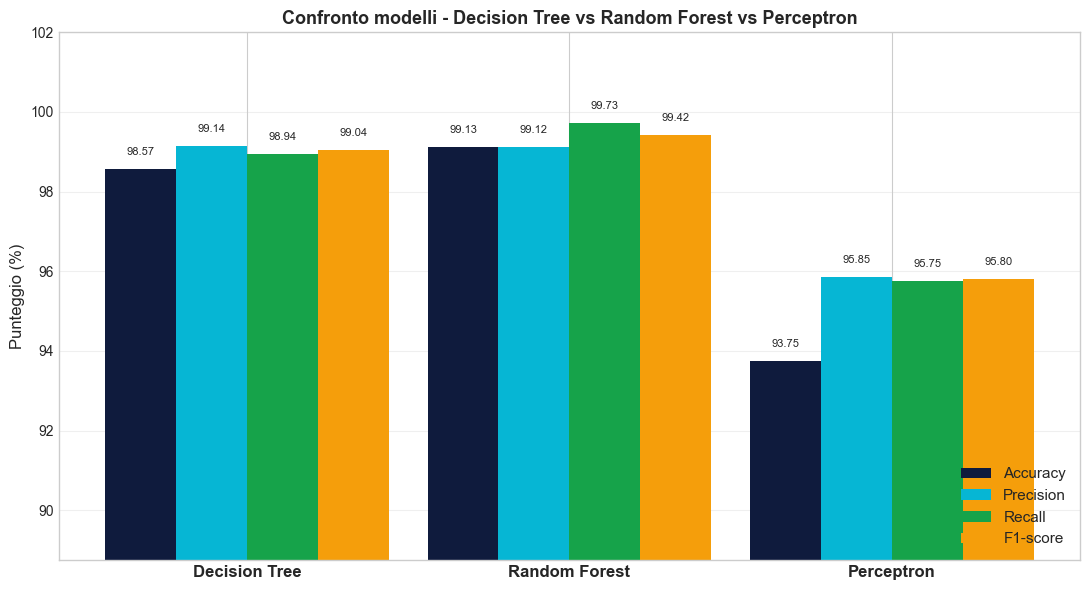

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')

x = np.arange(len(results_df))
width = 0.22

bars1 = ax.bar(x - 1.5*width, results_df['Accuracy'],  width, label='Accuracy',  color='#0F1B3D')
bars2 = ax.bar(x - 0.5*width, results_df['Precision'], width, label='Precision', color='#06B6D4')
bars3 = ax.bar(x + 0.5*width, results_df['Recall'],    width, label='Recall',    color='#16A34A')
bars4 = ax.bar(x + 1.5*width, results_df['F1-score'],  width, label='F1-score',  color='#F59E0B')

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Modello'], fontsize=12, fontweight='bold')
ax.set_ylabel('Punteggio (%)', fontsize=12)
ax.set_title('Confronto modelli - Decision Tree vs Random Forest vs Perceptron',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ymin = results_df[['Accuracy','Precision','Recall','F1-score']].values.min() - 5
ax.set_ylim(ymin, 102)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../output/models_comparison.png', dpi=150, bbox_inches='tight')
print('Salvato: ../output/models_comparison.png')
plt.show()

## 6. Matrici di confusione affiancate

Salvato: ../output/confusion_matrices_comparison.png


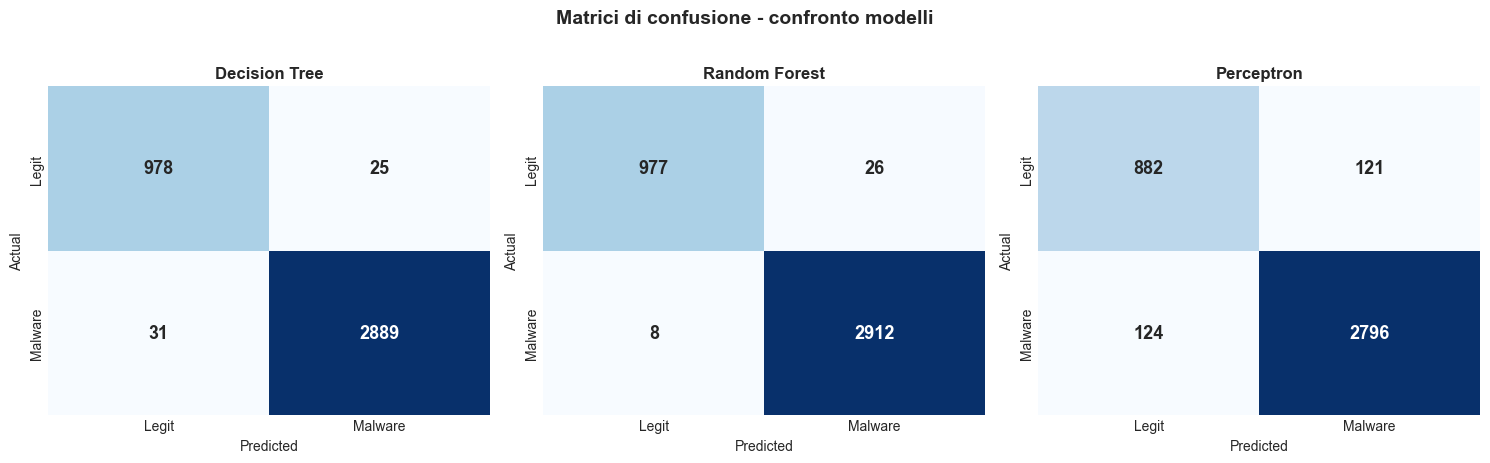

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor('white')

for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legit', 'Malware'],
                yticklabels=['Legit', 'Malware'], ax=ax,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Matrici di confusione - confronto modelli',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
print('Salvato: ../output/confusion_matrices_comparison.png')
plt.show()

## 7. Interpretazione dei risultati

### Random Forest > Decision Tree
La RF sfrutta il **voto di maggioranza** di molti alberi addestrati su sottoinsiemi diversi (bootstrap) e con feature diverse a ogni split. Questo riduce la varianza e mitiga l'overfitting tipico del Decision Tree singolo.

### Decision Tree > Perceptron
Il Perceptron e un **classificatore lineare**: divide lo spazio delle feature con un iperpiano. Il problema malware/legit ha confini decisionali altamente non-lineari (lo dimostrano le decisioni a soglia che il DT impara con successo). Inoltre il Perceptron **soffre con dataset sbilanciati** (il nostro IR=2,9), tendendo a sbagliare di piu sulla classe minoritaria.

### Conferma empirica
Il risultato **giustifica scientificamente** la scelta della Random Forest come modello finale: non e una scelta arbitraria, ma la conseguenza di un confronto controllato tra tre famiglie diverse di classificatori.

## 8. Riepilogo

In [7]:
print('=' * 80)
print('  RIEPILOGO FINALE')
print('=' * 80)
print()
print('Tabella metriche (in %):')
print(results_df[['Modello','Accuracy','Precision','Recall','F1-score']].to_string(index=False))
print()
print('Confusion matrix (su 3.922 campioni di test):')
print(results_df[['Modello','TP','FN','FP','TN']].to_string(index=False))
print()
print('Ranking finale: Random Forest > Decision Tree > Perceptron')
print('Conferma: il problema e non-lineare, l\'ensemble batte il singolo albero.')

  RIEPILOGO FINALE

Tabella metriche (in %):
      Modello  Accuracy  Precision  Recall  F1-score
Decision Tree     98.57      99.14   98.94     99.04
Random Forest     99.13      99.12   99.73     99.42
   Perceptron     93.75      95.85   95.75     95.80

Confusion matrix (su 3.922 campioni di test):
      Modello   TP  FN  FP  TN
Decision Tree 2889  31  25 978
Random Forest 2912   8  26 977
   Perceptron 2796 124 121 882

Ranking finale: Random Forest > Decision Tree > Perceptron
Conferma: il problema e non-lineare, l'ensemble batte il singolo albero.
